In [1]:
###NN deep learning 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from keras.layers import Dense, Dropout

data = pd.read_csv('D:/bachelor semester/datasets/turbo_fans_with_RUL.csv')

index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
uslesssensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']

from sklearn.model_selection import train_test_split

drop_labels = index_names + setting_names + uslesssensors
x = data.drop(drop_labels, axis=1)
y = data['RUL']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=2)


x_train.drop(columns=['RUL'], inplace=True)
x_test.drop(columns=['RUL'], inplace=True)
scaler = MinMaxScaler()
x_train_scale=scaler.fit_transform(x_train)
x_test_scale=scaler.transform(x_test)

print(x_train_scale)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20832\1265757389.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd



[[0.55120482 0.38739917 0.38561279 ... 0.5        0.47286822 0.61862245]
 [0.49698795 0.60344452 0.53872114 ... 0.58333333 0.31782946 0.41907596]
 [0.27710843 0.48070634 0.37690941 ... 0.41666667 0.54263566 0.6662415 ]
 ...
 [0.44578313 0.37671681 0.35612789 ... 0.41666667 0.4496124  0.62514172]
 [0.46987952 0.4028777  0.25701599 ... 0.41666667 0.46511628 0.60289116]
 [0.44879518 0.37758884 0.43357016 ... 0.41666667 0.56589147 0.58078231]]


In [2]:
#evaluating functions
#R2 score & RMSE & MAER
def evaluate(y_true, y_hat, label='test'):
    mse = mean_squared_error(y_true, y_hat)
    rmse = np.sqrt(mse)
    variance = r2_score(y_true, y_hat)
    print('{} set RMSE:{}, R2:{}'.format(label, rmse, variance))


#plot real data and the predicted one to make some comparison
def plot_predActual(y_test, y_test_hat):
  
    indices = np.arange(len(y_test_hat))
    wth= 0.6
    plt.figure(figsize=(70,30))
    true_values = [int(x) for x in y_test.values]
    predicted_values = list(y_test_hat)

    plt.bar(indices, true_values, width=wth,color='b', label='True RUL')
    plt.bar([i for i in indices], predicted_values, width=0.5*wth, color='r', alpha=0.7, label='Predicted RUL')

    plt.legend(prop={'size': 40})
    plt.tick_params(labelsize=40)

    plt.show()

def plot_result(y_true, y_pred):
    plt.figure(figsize=(70, 30))
    plt.plot(y_pred, linewidth=7) 
    plt.plot(y_true, linewidth=7)  
    plt.tick_params(labelsize=40)
    plt.ylabel('RUL', fontsize=40)  # Increase font size for y-axis label
    plt.xlabel('Training Samples', fontsize=40)  # Increase font size for x-axis label
    plt.legend(('Predicted', 'True'), loc='upper right', fontsize=40)  # Increase font size for legend
    plt.show()

In [3]:
modelNN = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1) 
])

modelNN.compile(optimizer='adam', loss='mean_squared_error')

history = modelNN.fit(x_train_scale, y_train, validation_split=0.1, epochs=100)






Epoch 1/100

407/407 [==============================] - 1s 1ms/step - loss: 6745.3105 - val_loss: 2278.4917
Epoch 2/100
407/407 [==============================] - 0s 992us/step - loss: 2062.5681 - val_loss: 1977.1431
Epoch 3/100
407/407 [==============================] - 0s 1ms/step - loss: 1946.9412 - val_loss: 1898.2308
Epoch 4/100
407/407 [==============================] - 0s 1ms/step - loss: 1895.3785 - val_loss: 1862.9425
Epoch 5/100
407/407 [==============================] - 0s 974us/step - loss: 1857.2911 - val_loss: 1852.8872
Epoch 6/100
407/407 [==============================] - 0s 1ms/step - loss: 1837.6586 - val_loss: 1863.9839
Epoch 7/100
407/407 [==============================] - 0s 954us/step - loss: 1820.6930 - val_loss: 1822.2803
Epoch 8/100
407/407 [==============================] - 0s 1ms/step - loss: 1797.8579 - val_loss: 1803.3813
Epoch 9/100
407/407 [==============================] - 0s 952us/step - loss: 1783.6262 - val_loss: 1793.5129
Epoch 10/100
407/407 [====

In [5]:
y_lr_train = modelNN.predict(x_train_scale) #Prediction on train data


y_lr_test = modelNN.predict(x_test_scale)  #Prediction on test data

evaluate(y_test, y_lr_test, label='test')
evaluate(y_train,y_lr_train, label='train')

194/194 [==============================] - 0s 722us/step
test set RMSE:41.54595587053294, R2:0.6482121529512861
train set RMSE:40.681395332825446, R2:0.6459767799724165


194/194 [==============================] - 0s 723us/step


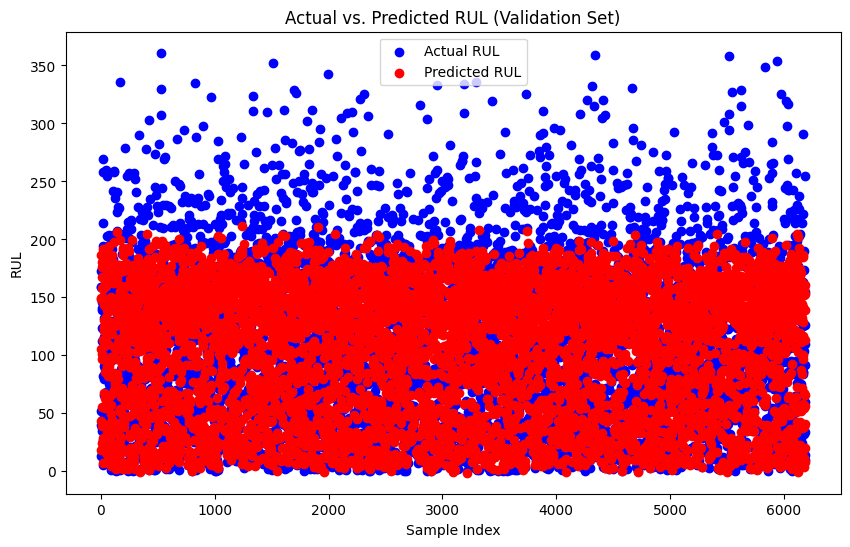

In [6]:
y_pred = modelNN.predict(x_test_scale)
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='b', label='Actual RUL')
plt.scatter(range(len(y_pred)), y_pred, color='r', label='Predicted RUL')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.title('Actual vs. Predicted RUL (Validation Set)')
plt.legend()
plt.show()

In [7]:

# Input values
input_values1 = (641.89,1583.84,1391.28,554.53,2388.01,9054.72,46.93,522.33,2388.06,8137.72,8.3905,391,38.94,23.4585)
#286
input_values2 = (642.36,1582.64,1399.51,554.77,2387.95,9056.36,47.26,522.59,2387.96,8140.14,8.3952,393,39.1,23.2916)
#200
input_values3 = (642.01,1587.73,1392.94,554.41,2388.05,9054.47,47.32,521.88,2388.07,8138.95,8.4199,392,38.92,23.406)
#131
input_values4 = (642.69,1588.88,1407.54,553.32,2388.08,9060.97,47.51,521.09,2388.05,8136.8,8.4101,392,38.93,23.3926)
#100
input_values5 = (643.14,1593.05,1419.76,552.78,2388.11,9069.61,47.65,520.7,2388.12,8152.81,8.4742,394,38.57,23.2618)
#50
input_values6 = (643.91,1601.35,1430.04,551.96,2388.22,9089.87,48.18,519.95,2388.21,8166.83,8.5291,395,38.23,23.1196)
#3

# Convert input values to a NumPy array
input_arr1 = np.asarray(input_values1)
input_arr2 = np.asarray(input_values2)
input_arr3 = np.asarray(input_values3)
input_arr4 = np.asarray(input_values4)
input_arr5 = np.asarray(input_values5)
input_arr6 = np.asarray(input_values6)

# Reshape the array to match the expected input shape of the model
input_reshaped1 = input_arr1.reshape(1, -1)  
input_reshaped2 = input_arr2.reshape(1, -1) 
input_reshaped3 = input_arr3.reshape(1, -1) 
input_reshaped4 = input_arr4.reshape(1, -1) 
input_reshaped5 = input_arr5.reshape(1, -1) 
input_reshaped6 = input_arr6.reshape(1, -1)

scaled_array1 = scaler.transform(input_reshaped1)
scaled_array2 = scaler.transform(input_reshaped2)
scaled_array3 = scaler.transform(input_reshaped3)
scaled_array4 = scaler.transform(input_reshaped4)
scaled_array5 = scaler.transform(input_reshaped5)
scaled_array6 = scaler.transform(input_reshaped6)

prediction1 = modelNN.predict(scaled_array1)
prediction2 = modelNN.predict(scaled_array2)
prediction3 = modelNN.predict(scaled_array3)
prediction4 = modelNN.predict(scaled_array4)
prediction5 = modelNN.predict(scaled_array5)
prediction6 = modelNN.predict(scaled_array6)

print('scaled_array1',scaled_array1)
print('scaled_array2',scaled_array2)
print('scaled_array3',scaled_array3)
print('scaled_array4',scaled_array4)
print('scaled_array5',scaled_array5)
print('scaled_array6',scaled_array6)


def predict_risk(prediction):
    zz = ""
    if prediction < 0 or (prediction > 0 and prediction < 50):
        zz = "risk"
    elif prediction > 50 and prediction < 150:
        zz = "moderated risk"
    else:
        zz = "No risk"
    
    print("Predicted RUL:", prediction, zz)

predict_risk(prediction1)
predict_risk(prediction2)
predict_risk(prediction3)
predict_risk(prediction4)
predict_risk(prediction5)
predict_risk(prediction6)

1/1 [==============================] - 0s 3ms/step


C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\base.py:493: UserWarning: X

1/1 [==============================] - 0s 8ms/step
scaled_array1 [[0.20481928 0.27904949 0.10817052 0.75905797 0.16666667 0.14803015
  0.04191617 0.7761194  0.26153846 0.19496336 0.26094206 0.25
  0.62015504 0.78146259]]
scaled_array2 [[0.34638554 0.2528886  0.25435169 0.80253623 0.07575758 0.15538903
  0.23952096 0.8315565  0.10769231 0.20745175 0.28053356 0.41666667
  0.74418605 0.5449263 ]]
scaled_array3 [[0.24096386 0.36385437 0.13765542 0.73731884 0.22727273 0.14690837
  0.2754491  0.68017058 0.27692308 0.20131076 0.38349312 0.33333333
  0.60465116 0.70705782]]
scaled_array4 [[0.44578313 0.38892522 0.39698046 0.53985507 0.27272727 0.17607467
  0.38922156 0.51172708 0.24615385 0.19021571 0.34264277 0.33333333
  0.6124031  0.68806689]]
scaled_array5 [[0.5813253  0.47983431 0.61403197 0.44202899 0.31818182 0.2148434
  0.47305389 0.42857143 0.35384615 0.27283517 0.60983743 0.5
  0.33333333 0.50269274]]
scaled_array6 [[0.81325301 0.66078047 0.79662522 0.29347826 0.48484848 0.30575249
 

In [5]:
#from tinymlgen import port 
#c_code=port(model,pretty_print=True)
#print(c_code)


In [16]:
#convert model to tensorflow lite
#converter =tf.lite.TFLiteConverter.from_keras_model(model)
#tflite_model=converter.convert()

#open("turbo_modelscale.tflite","wb").write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\Lenovo\AppData\Local\Temp\tmp1d3mw3vd\assets


INFO:tensorflow:Assets written to: C:\Users\Lenovo\AppData\Local\Temp\tmp1d3mw3vd\assets


22620